# Mean-Field Dynamics of Self-Training in Gradient Descent

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
torch.set_default_dtype(torch.float64)

from matplotlib import pyplot as plt

from scipy.special import logit
from scipy.stats import norm

In [3]:
import sys
import os
sys.path.append(os.path.abspath('/Users/thierryrioual/Desktop/Princeton/Academics/Research/implementation'))

from src.config import DataConfig, AlgorithmConfig
from src.objectives import LipschitzSelection, SmoothSelection, HardSelection
from src.dgp import IsotropicGaussian
from src.asymptotics import MacroscopicStateEvolution
from src.algorithms import SelfTrainedGradientDescent
from src.callbacks import TestEvaluatorCallback
from src.utils import plot_autograd_dag

from scripts.runner import MonteCarloExperiment

## Model definition

We consider a quenched high-dimensional binary Gaussian mixture model under partial supervision.

---

### Asymptotic parameters

Throughout, we fix the following asymptotic parameters:

$$
\delta \in (0,\infty), \quad
\rho \in (0,1), \quad
p \in (0,1), \quad
\nu_\mu \in \mathscr P_2(\mathbb R), \quad
\sigma \in (0,\infty).
$$

Here, $\delta$ denotes the sample-to-dimension ratio, $\rho$ the supervision ratio, $p$ the class prior, $\nu_\mu$ the limiting signal law, and $\sigma$ the noise level.

---

### Data-generating process

Unless otherwise stated, all quantities are implicitly indexed by the dimension $d$, although this dependence is omitted from the notation whenever it causes no ambiguity.

For each dimension $d \ge 1$, let

- $\mu \in \mathbb R^d$ be a deterministic signal vector,
- $n \in \mathbb{N}^*$ be the sample size,
- $\Delta \in \{0,1\}^n$ be a deterministic observability mask.

The mask partitions the sample indices into the labeled and unlabeled sets

$$
I_{\mathcal L}
:=
\{i\in[\![1,n]\!]:\Delta_i=1\},
\quad
I_{\mathcal U}
:=
\{i\in[\![1,n]\!]:\Delta_i=0\},
$$

with respective cardinalities

$$
N:=|I_{\mathcal L}|,
\quad
M:=|I_{\mathcal U}|=n-N.
$$

Without loss of generality, we assume that

$$
I_{\mathcal L}=[\![1,N]\!],
\quad
I_{\mathcal U}=[\![N+1,N+M]\!].
$$

On a probability space $(\Omega,\mathcal F,\mathbb P)$, let
$(Y_i,U_i)_{i=1}^n$ be i.i.d. random variables satisfying

$$
\frac{Y_i+1}{2}\sim\operatorname{Bernoulli}(p),
\quad
U_i\sim\mathcal N(0_d,I_d),
\quad
Y_i\perp\!\!\!\perp U_i.
$$

The observed covariates are generated according to

$$
X_i=\frac{1}{\sqrt d}Y_i\mu+\sigma U_i,
\quad
i=1,\ldots,n.
$$

The labeled and unlabeled datasets are then given by

$$
\mathcal L
:=
\{(X_i,Y_i):i\in I_{\mathcal L}\},
\quad
\mathcal U
:=
\{X_j:j\in I_{\mathcal U}\}.
$$

---

### High-dimensional asymptotic regime

For each $d$, let

$$
\nu_\mu^{(d)}
:=
\frac1d\sum_{k=1}^d\delta_{\mu_k}
$$

denote the empirical distribution of the coordinates of the signal vector.

We consider the proportional asymptotic regime in which, as $d\to\infty$,

$$
\nu_\mu^{(d)}
\xrightarrow{W_2}
\nu_\mu,
\quad
\frac nd\longrightarrow\delta,
\quad
\frac Nn\longrightarrow\rho.
$$

In particular, the empirical distribution of the coordinates of the signal vector converges in Wasserstein distance to the prescribed signal law $\nu_\mu$.

In [4]:
# Defining Asymptotic Parameters

delta = 20.0
rho = 0.01
p = 0.2
sigma = 1.0

def nu_mu(seed: int = None, mean: float = 1.0, std: float = 1.0) -> float:
    """
    A deterministic function mapping (seed, index) pairs to a normal distribution.
    If seed is None, it acts like a standard random sampler.
    """
    rng = None if seed is None else torch.Generator().manual_seed(seed)
    return torch.normal(mean=mean, std=std, size=(1,), generator=rng).item()

In [5]:
# Generating Data

data_cfg = DataConfig(
    scale=sigma,
    label_prior=p,
    supervision_ratio=rho,
    data_to_dimension_ratio=delta,
    signal_law=nu_mu,  
)

data = IsotropicGaussian(
    cfg=data_cfg, 
    n_train=10000,
    n_test=5000,
    dimensions=500,
    seed=42
)

X_lab, Y_lab, X_unl, Y_unl, X_test, Y_test = data.sample()

## Algorithm definition

We consider a gradient descent-based self-training algorithm for linear prediction with pseudo-labeled data.

---

### Objective

The goal is to predict the label $Y_i$ from the covariate $X_i$ using both labeled and unlabeled observations. Given the labeled dataset $\mathcal L$ and the unlabeled dataset $\mathcal U$, we aim to leverage the unlabeled samples through a self-training procedure.

We restrict the hypothesis class to linear classifiers of the form

$$
f_{b,w}(x)
=
\operatorname{sign}
\left(
b+\frac{w^\top x}{\sqrt d}
\right), 
$$

where $(b,w)\in\mathbb R\times\mathbb R^d$ are respectively the bias and the weight vector, and the sign function is defined as

$$
\operatorname{sign}(x)
=
\mathbf 1_{[0,\infty)}(x)
-
\mathbf 1_{(-\infty,0)}(x).
$$

We consider a empirical risk minimization framework with regularization. The distinguishing feature of the present setting is the use of pseudo-labeled observations generated from the unlabeled dataset.

Let

$$
\ell:\{-1,1\}\times\mathbb R\to\mathbb R,
\quad
J:\mathbb R^d\to\mathbb R
$$

denote respectively a loss function and a penalty function.

---

### Self-training procedure

The algorithm consists of three successive phases.

* **Supervised initialization.** We first perform supervised learning using only the labeled dataset. Starting from an initial point, gradient descent is applied to minimize the regularized empirical risk associated with the labeled observations, yielding an initial classifier obtained solely from the supervised information.

* **Pseudo-label generation and burn-in phase.** The resulting classifier is then used to generate pseudo-labels for selected unlabeled observations. Specifically, each unlabeled sample is assigned a pseudo-label according to the current prediction of the classifier, and only predictions satisfying a prescribed confidence criterion are retained. These pseudo-labeled observations are subsequently incorporated into the empirical risk. To avoid abrupt changes in the optimization dynamics, the contribution of the pseudo-labeled loss is gradually increased from zero to a fixed value through a linear schedule. This gradual transition is referred to as the burn-in period.

* **Self-training phase.** After the burn-in period, the algorithm continues optimizing the empirical risk over the augmented dataset consisting of both labeled and pseudo-labeled observations. The pseudo-labeled loss is assigned a fixed weight, allowing the algorithm to leverage the additional information contained in the unlabeled dataset while maintaining a stable optimization procedure.
---

### Hyperparameters

The algorithm depends on the following hyperparameters:

$$
T\in\mathbb N^*,
\quad
\eta\in(0,\infty),
\quad
\lambda\in[0,\infty),
\quad
\pi\in[0,\infty),
$$

$$
(T_0,T_1)\in(\mathbb N^*)^2,
\quad
\kappa=(\kappa_-,\kappa_+)\in\mathbb R^2.
$$

Here:

- $T$ is the total number of gradient descent iterations;
- $\eta$ is the learning rate;
- $\lambda$ is the regularization parameter;
- $\pi$ controls the asymptotic contribution of pseudo-labeled samples;
- $(T_0,T_1)$ determine the ramp-up schedule for pseudo-label incorporation;
- $\kappa$ defines the confidence thresholds used for pseudo-label selection.

The ramp parameters satisfy

$$
0\leq T_0<T_1\leq T,
$$

and the confidence thresholds satisfy

$$
\kappa_-<0<\kappa_+.
$$

We define the selection function
$
S_\kappa:\mathbb R\to\{0,1\}
$
by

$$
S_\kappa(r)
=
\mathbf 1_{(-\infty,\kappa_-]\cup[\kappa_+,\infty)}(r).
$$

The pseudo-label contribution is controlled through the schedule
$(\pi_t)_{t\in[\![0,T]\!]}$, defined by

$$
\pi_t=
\begin{cases}
0,
& t\in[\![0,T_0]\!], \\
\left(\dfrac{t-T_0}{T_1-T_0}\right)\pi,
& t\in[\![T_0,T_1]\!], \\
\pi,
& t\in[\![T_1,T]\!].
\end{cases}
$$

---

### Gradient descent iterations

At iteration $t \in [\![0,T]\!]$, define the preactivations

$$
r_i^t
=
b^t+\frac{1}{\sqrt d}X_i^\top w^t, \quad i \in [\![1,n]\!]
$$

and the pseudo-labels

$$
\hat Y_j^t
=
\operatorname{sign}(r_j^t),
\quad
j\in I_{\mathcal U}.
$$


The fraction of selected pseudo-labeled observations is

$$
A_t
=
\frac1M
\sum_{j\in I_{\mathcal U}}
S_\kappa(r_j^t).
$$

We adopt the convention
$
\frac00=0
$
to handle the case where no unlabeled sample satisfies the confidence criterion.

At iteration $t$, the objective minimized by gradient descent is given by the function

$$
(b,w)
\mapsto
\frac1N
\sum_{i\in I_{\mathcal L}}
\ell(Y_i,r_i(b,w))
+
\frac{\pi_t}{M}
\sum_{j\in I_{\mathcal U}}
\ell(\hat Y_j^t,r_j(b,w))
\frac{S_\kappa(r_j^t)}{A_t}
+
\frac{\lambda}{d} J(w),
$$

where, for each $i \in [\![1, n]\!]$,

$$
r_i(b,w)
=
b+\frac1{\sqrt d}X_i^\top w.
$$

The initialization is given by

$$
b^0=b_{\mathrm{init}},
\quad
w^0=w_{\mathrm{init}}.
$$

The gradient descent updates are

$$
\begin{align*}
b^{t+1}
&=
b^t-\eta
\left(
\frac1N
\sum_{i\in I_{\mathcal L}}
\ell'(Y_i,r_i^t)
+
\frac{\pi_t}{M}
\sum_{j\in I_{\mathcal U}}
\ell'(\widehat Y_j^t,r_j^t)
\frac{S_\kappa(r_j^t)}{A_t}
\right),
\\
w^{t+1}
&=
w^t-\eta d
\left(
\frac1N
\sum_{i\in I_{\mathcal L}}
\ell'(Y_i,r_i^t)
\frac{X_i}{\sqrt d}
+
\frac{\pi_t}{M}
\sum_{j\in I_{\mathcal U}}
\ell'(\widehat Y_j^t,r_j^t)
\frac{X_j}{\sqrt d}
\frac{S_\kappa(r_j^t)}{A_t}
+
\frac{\lambda}{d} \nabla J(w^t)
\right).
\end{align*}
$$

Here, $\ell'$ denotes the derivative of the loss with respect to its second argument:

$$
\ell'(y,r)
=
\frac{\partial}{\partial r}\ell(y,r).
$$

In [ ]:
# Initializing the Self-Training Algorithm with callback

callback = TestEvaluatorCallback(
    X_lab=X_lab,
    Y_lab=Y_lab,
    X_unl=X_unl, 
    Y_unl=Y_unl,
    X_test=X_test, 
    Y_test=Y_test,
    mu=data._mu,
    sigma=data_cfg.scale,
    p=data_cfg.label_prior,
    metrics={
        "test_error", "population_error", "unl_usage", 
        "train_mean_residual", "train_label_residual_alignment", 
        "weight_signal_alignment", "weight_vector_norm", "bias_term"
    }
)

algorithm_cfg = AlgorithmConfig(
    n_iterations=1000,
    ramp_start=500,
    ramp_end=500,
    positive_margin=logit(0.95),
    negative_margin=-logit(0.70),
    penalty_param=0.1,
    step_size=0.1,
    pseudo_label_param=2.0,
    include_bias=True
)

st = SelfTrainedGradientDescent(cfg=algorithm_cfg, callback=callback)

In [17]:
torch.manual_seed(42)
st.fit(X_lab, Y_lab, X_unl)

## Analysis

To analyze the asymptotic behavior of the algorithm, it is convenient to rewrite the gradient descent iterations in vectorized form and introduce suitable aggregate quantities.

Throughout this section, we assume without loss of generality that
$
\sigma=1.
$
Indeed, the noise variance can be absorbed into the signal vector through a rescaling argument, and the general case can be recovered by an appropriate change of variables.

---

### Vectorization and function definitions

Let

$$
Y
=
\begin{bmatrix}
Y_1\\
\vdots\\
Y_n
\end{bmatrix}
\in\mathbb R^n,
\qquad
U
=
\begin{bmatrix}
U_1^\top\\
\vdots\\
U_n^\top
\end{bmatrix}
\in\mathbb R^{n\times d}.
$$

The design matrix can then be written as

$$
X
=
\frac1{\sqrt d}Y\mu^\top+U
\in\mathbb R^{n\times d}.
$$

For each iteration $t \in [\![0,T]\!] $ and each sample index $i\in[\![1,n]\!]$, define the scalar update function
$
g_i^t:\mathbb R\to\mathbb R
$
by

$$
g_i^t(r)
=
\mathcal G(r;Y_i,\Delta_i,\pi_t,A_t),
$$

where

$$
\mathcal G(r;y,\Delta,\pi,A)
=
-\eta
\left(
\frac{\Delta}{N/n}\ell'(y,r)
+
\pi
\frac{1-\Delta}{M/n}
\ell'(\operatorname{sign}(r),r)
\frac{S_\kappa(r)}{A}
\right).
$$

We then define the vector-valued map
$
g^t:\mathbb R^n\to\mathbb R^n
$
componentwise as

$$
g^t(r_1,\ldots,r_n)
=
\bigl(
g_1^t(r_1),\ldots,g_n^t(r_n)
\bigr).
$$

At iteration $t$, we write

$$
g^t:=g^t(r^t)
$$

and refer to this vector as the pseudo-residual.
(This terminology follows the convention used in the gradient boosting literature.)

Similarly, define the regularization contribution
$
h^t:\mathbb R^d\to\mathbb R^d
$
by

$$
h^t(w_1, \dots, w_d)
=
-\eta\lambda\nabla J(w_1, \dots, w_d).
$$

We use the notation

$$
h^t:=h^t(w^t)
$$

for the value of this term at iteration $t$, and refer to it as the decay term.

---

### Vectorized gradient descent iterations

With the above notation, the gradient descent iterations can be expressed as

$$
\begin{cases}
r^t
=
b^t1_n+\dfrac1{\sqrt d}Xw^t,\\[0.5em]
b^{t+1}
=
b^t+\dfrac1n1_n^\top g^t,\\[0.5em]
w^{t+1}
=
w^t+\dfrac{\sqrt d}{n}X^\top g^t+h^t.
\end{cases}
$$

Using the decomposition of the design matrix, this is equivalently written as

$$
\begin{cases}
r^t
=
b^t1_n
+
\dfrac{\mu^\top w^t}{d}Y
+
\dfrac{Uw^t}{\sqrt d},
\\[0.8em]
b^{t+1}
=
b^t+\dfrac1n1_n^\top g^t,
\\[0.8em]
w^{t+1}
=
w^t+h^t
+
\dfrac{Y^\top g^t}{n}\mu
+
\sqrt{\dfrac dn}\dfrac{U^\top g^t}{\sqrt n}.
\end{cases}
$$

---

### Macroscopic quantities and fluctuation terms

We introduce the following scalar quantities, which describe the macroscopic evolution of the algorithm:

$$
m_t
=
\frac{\mu^\top w^t}{d},
\quad
\chi_t
=
\frac{Y^\top g^t}{n},
\quad
\zeta_t
=
\frac{1_n^\top g^t}{n}.
$$

Here, $m_t$ is the weight-signal alignment, $\chi_t$ the label-residual alignment, and $\zeta_t$ the mean residual.

We also define 
$$
q^t
=
\frac{Uw^t}{\sqrt d}
\in\mathbb R^n,
\quad
p^t
=
\frac{U^\top g^t}{\sqrt n}
\in\mathbb R^d,
$$
the forward noise vector and the backward noise vector, respectively.

In terms of these quantities, the gradient descent dynamics become

$$
\begin{cases}
r^t
=
b^t1_n+m_tY+q^t,
\\[0.5em]
b^{t+1}
=
b^t+\zeta_t,
\\[0.5em]
w^{t+1}
=
w^t+h^t+\chi_t\mu+\frac1{\sqrt{n/d}}p^t.
\end{cases}
$$

### Gaussian Conditioning

$$
\begin{align*}
U \stackrel{d}{=}_{\mathcal{F}_t}  U \Pi_{W_{t-1}} + \Pi_{G_{t-1}} U \Pi_{W_{t-1}}^\perp + \Pi_{G_{t-1}}^\perp \check U \Pi_{W_{t-1}}^\perp
\end{align*}
$$

$$
\begin{align*}
q^t &\stackrel{d}{=}_{\mathcal{F}_t} \frac{1}{\sqrt d} \left( U \Pi_{W_{t-1}} w^t + \Pi_{G_{t-1}} U \Pi_{W_{t-1}}^\perp w^t + \Pi_{G_{t-1}}^\perp \check U \Pi_{W_{t-1}}^\perp w^t \right) \\
&= Q_{t-1} \alpha^t + \frac{\sqrt n}{\sqrt d}G_{t-1} ( G_{t-1}^\top G_{t-1})^{-1} P_t^\top (w^t - W_{t-1} \alpha^t) + \frac{1}{\sqrt d}\Pi_{G_{t-1}}^\perp \check U \Pi_{W_{t-1}}^\perp w^t \\
&= Q_{t-1} \alpha^t + \frac{\sqrt n}{\sqrt d} G_{t-1} (\gamma^{[w]}_t - \Gamma_{t-1}^{[w]} \alpha^t) + \frac{1}{\sqrt d} \check U \Pi_{W_{t-1}}^\perp w^t +o(1)
\end{align*}
$$
From Bayati and Montanari.

$$
Q_{t-1} = G_{t-1} \Gamma^{[w]}_{t-1} + \Omega_{t-1}
$$

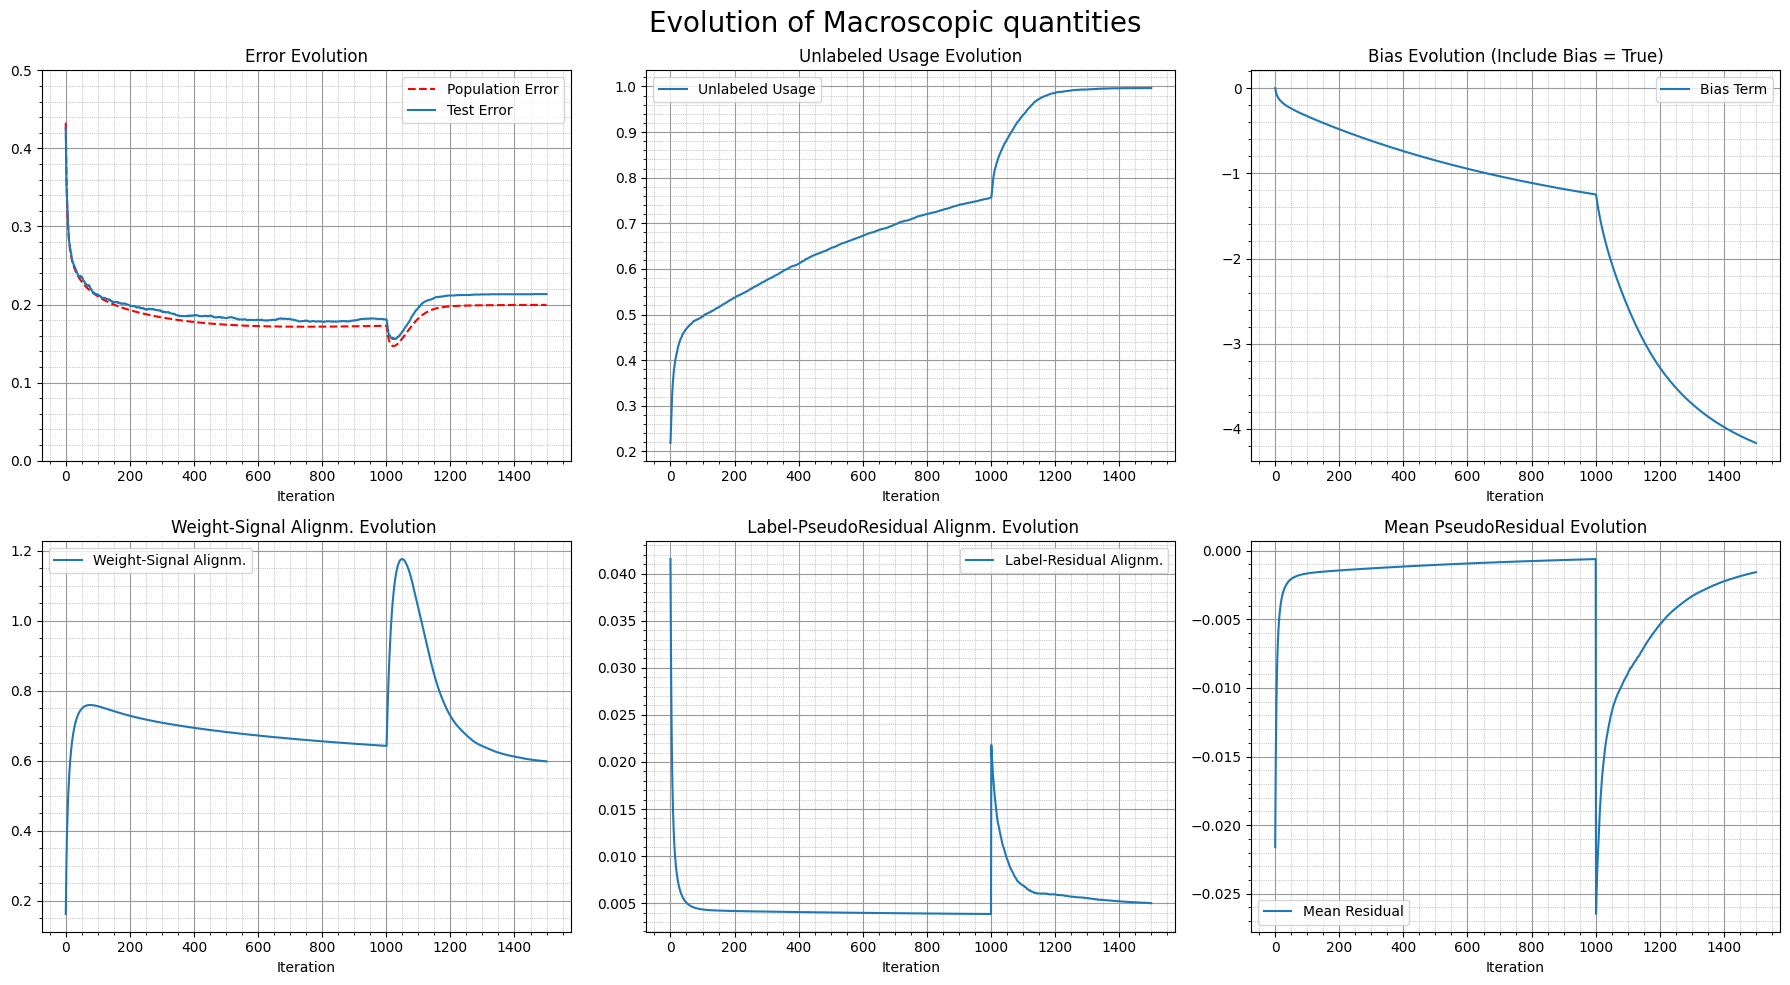

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Plot 1: Errors ---
axes[0, 0].plot(
    callback.history_["population_error"], label='Population Error', 
    linestyle='--', color='red'
)
axes[0, 0].plot(callback.history_["test_error"], label='Test Error')
axes[0, 0].set_ylim(0.0, 0.5)
axes[0, 0].set_title(f'Error Evolution')

# --- Plot 2: Unlabeled Usage ---
axes[0, 1].plot(callback.history_["unl_usage"], label='Unlabeled Usage')
axes[0, 1].set_title('Unlabeled Usage Evolution')

# --- Plot 3: Bias Term ---
axes[0, 2].plot(callback.history_["bias_term"], label='Bias Term')
axes[0, 2].set_title(
    f'Bias Evolution (Include Bias = {algorithm_cfg.include_bias})'
)

# --- Plot 4: Weight-Signal Alignment ---
axes[1, 0].plot(
    callback.history_["weight_signal_alignment"], 
    label="Weight-Signal Alignm."
)
axes[1, 0].set_title(f'Weight-Signal Alignm. Evolution ')

# --- Plot 5: Label-PseudoResidual Alignment ---
axes[1, 1].plot(
    callback.history_["train_label_residual_alignment"], 
    label="Label-Residual Alignm."
)
axes[1, 1].set_title(' Label-PseudoResidual Alignm. Evolution')

# --- Plot 6: Mean PseudoResidual ---
axes[1, 2].plot(
    callback.history_["train_mean_residual"], 
    label="Mean Residual"
)
axes[1, 2].set_title('Mean PseudoResidual Evolution')

for ax in axes.flatten():
    ax.set_xlabel('Iteration')
    ax.legend()
    ax.grid(which='major', color='#999999', linestyle='-', linewidth=0.8)
    ax.grid(which='minor', color='#999999', linestyle=':', linewidth=0.5)
    ax.minorticks_on()

fig.suptitle("Evolution of Macroscopic quantities", fontsize=20)


plt.tight_layout()
plt.show()

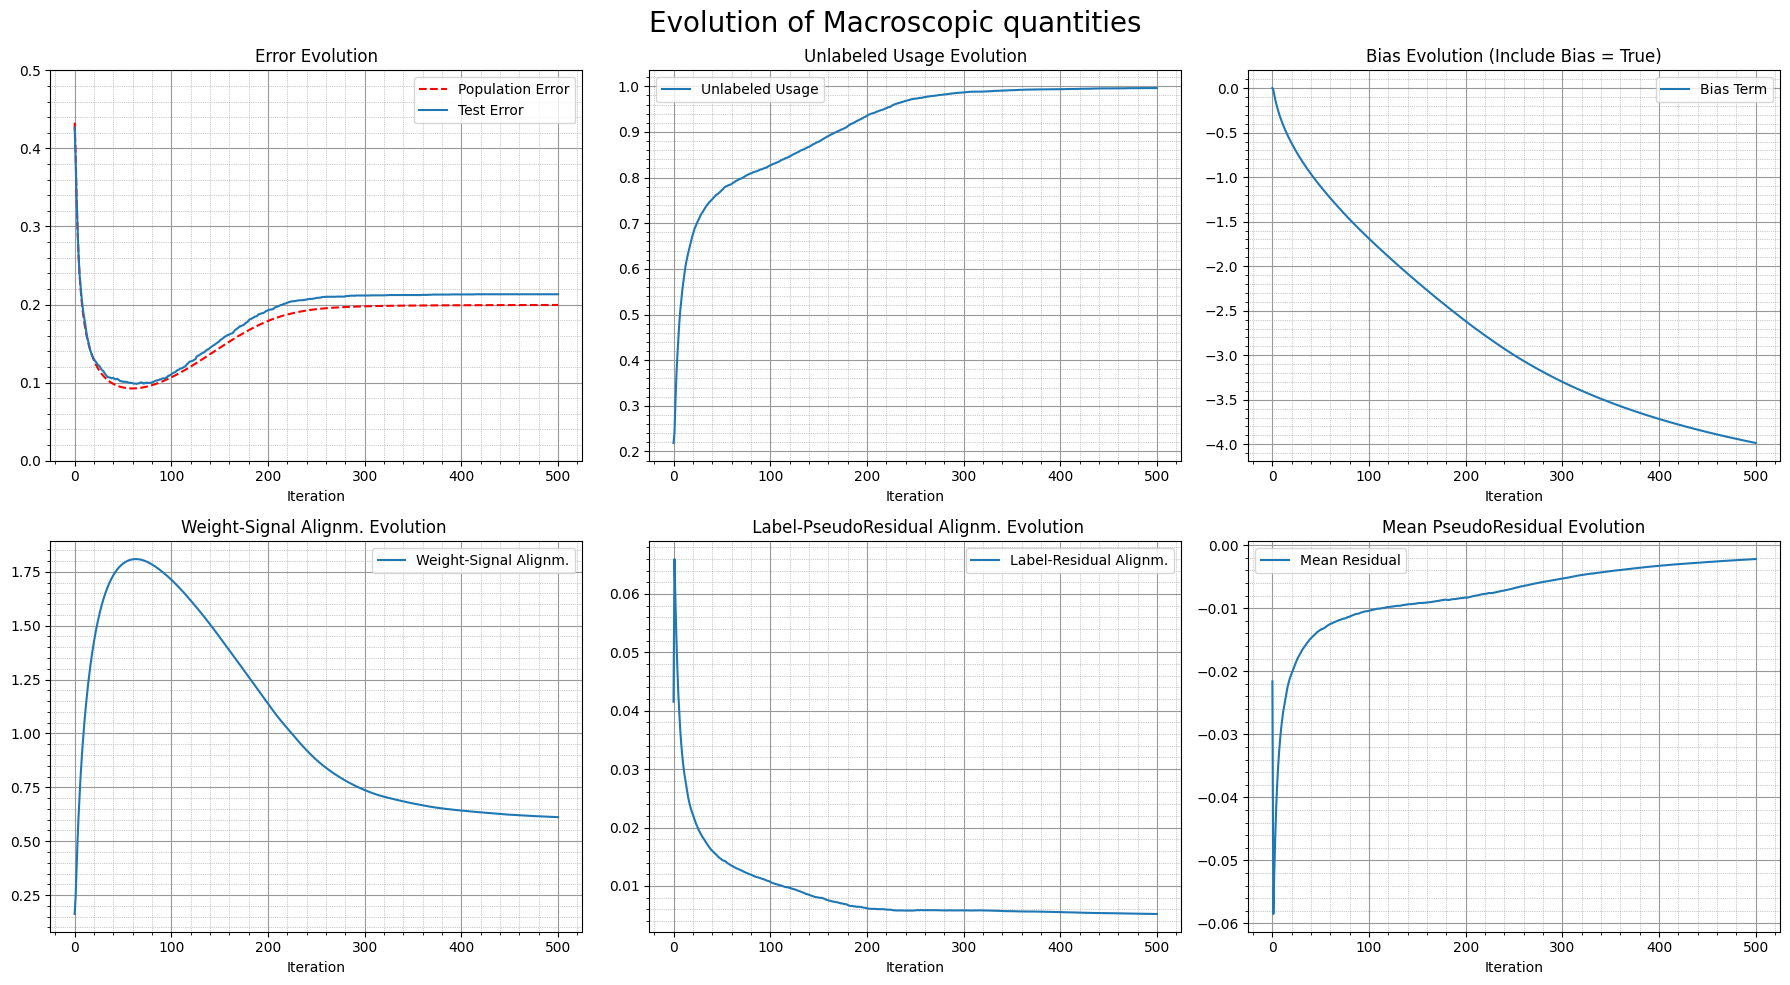

In [12]:
# Initializing the Self-Training Algorithm with callback

callback = TestEvaluatorCallback(
    X_lab=X_lab,
    Y_lab=Y_lab,
    X_unl=X_unl, 
    Y_unl=Y_unl,
    X_test=X_test, 
    Y_test=Y_test,
    mu=data._mu,
    sigma=data_cfg.scale,
    p=data_cfg.label_prior,
    metrics={
        "test_error", "population_error", "unl_usage", 
        "train_mean_residual", "train_label_residual_alignment", 
        "weight_signal_alignment", "weight_vector_norm", "bias_term"
    }
)

algorithm_cfg = AlgorithmConfig(
    n_iterations=500,
    ramp_start=0,
    ramp_end=0,
    positive_margin=logit(0.95),
    negative_margin=-logit(0.7),
    penalty_param=0.1,
    step_size=0.1,
    pseudo_label_param=2.0,
    include_bias=True
)

st = SelfTrainedGradientDescent(cfg=algorithm_cfg, callback=callback)

torch.manual_seed(42)
st.fit(X_lab, Y_lab, X_unl)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Plot 1: Errors ---
axes[0, 0].plot(
    callback.history_["population_error"], label='Population Error', 
    linestyle='--', color='red'
)
axes[0, 0].plot(callback.history_["test_error"], label='Test Error')
axes[0, 0].set_ylim(0.0, 0.5)
axes[0, 0].set_title(f'Error Evolution')

# --- Plot 2: Unlabeled Usage ---
axes[0, 1].plot(callback.history_["unl_usage"], label='Unlabeled Usage')
axes[0, 1].set_title('Unlabeled Usage Evolution')

# --- Plot 3: Bias Term ---
axes[0, 2].plot(callback.history_["bias_term"], label='Bias Term')
axes[0, 2].set_title(
    f'Bias Evolution (Include Bias = {algorithm_cfg.include_bias})'
)

# --- Plot 4: Weight-Signal Alignment ---
axes[1, 0].plot(
    callback.history_["weight_signal_alignment"], 
    label="Weight-Signal Alignm."
)
axes[1, 0].set_title(f'Weight-Signal Alignm. Evolution ')

# --- Plot 5: Label-PseudoResidual Alignment ---
axes[1, 1].plot(
    callback.history_["train_label_residual_alignment"], 
    label="Label-Residual Alignm."
)
axes[1, 1].set_title(' Label-PseudoResidual Alignm. Evolution')

# --- Plot 6: Mean PseudoResidual ---
axes[1, 2].plot(
    callback.history_["train_mean_residual"], 
    label="Mean Residual"
)
axes[1, 2].set_title('Mean PseudoResidual Evolution')

for ax in axes.flatten():
    ax.set_xlabel('Iteration')
    ax.legend()
    ax.grid(which='major', color='#999999', linestyle='-', linewidth=0.8)
    ax.grid(which='minor', color='#999999', linestyle=':', linewidth=0.5)
    ax.minorticks_on()

fig.suptitle("Evolution of Macroscopic quantities", fontsize=20)


plt.tight_layout()
plt.show()

## Dynamical Mean-Field Theory

Dynamical mean-field theory originates from statistical mechanics and provides a framework for studying the high-dimensional behavior of interacting stochastic systems through a simpler model that approximates the original by averaging over degrees of freedom. 

In the present setting, the objective is to characterize the asymptotic evolution of the gradient descent iterates by establishing the convergence of suitable empirical measures toward deterministic mean-field laws.

---

### Trajectory matrices and empirical measures

To study the dynamics of the algorithm, we collect the iterates into trajectory matrices.

Define

$$
W_T
=
\begin{bmatrix}
w^0 & \cdots & w^T
\end{bmatrix}
\in\mathbb R^{d\times(T+1)},
\qquad
R_T
=
\begin{bmatrix}
r^0 & \cdots & r^T
\end{bmatrix}
\in\mathbb R^{n\times(T+1)}.
$$

For each coordinate $k\in[\![1,d]\!]$ and sample $i\in[\![1,n]\!]$, let

$$
W_T(k)
=
(w_k^0,\ldots,w_k^T)
\in\mathbb R^{T+1},
\qquad
R_T(i)
=
(r_i^0,\ldots,r_i^T)
\in\mathbb R^{T+1},
$$

denote the $k$-th and $i$-th rows of $W_T$ and $R_T$, respectively.

The central objects of interest are the empirical measures

$$
\nu_{W_T}
:=
\frac1d
\sum_{k=1}^d
\delta_{W_T(k)},
\qquad
\nu_{R_T}
:=
\frac1n
\sum_{i=1}^n
\delta_{R_T(i)},
$$

which are random probability measures on $\mathbb R^{T+1}$. They describe the empirical distribution of the coordinate trajectories of the weights and preactivations over the optimization horizon.

---

### Wasserstein convergence to the mean-field law

Our objective is to establish the convergence in probability of these empirical measures, with respect to the 2-Wasserstein topology, toward deterministic probability measures $\bar\nu_{W_T}, \bar\nu_{R_T} \in \mathscr{P}_2(\mathbb{R}^{T+1})$.
Namely,
$$
W_2(\nu_{W_T},\bar\nu_{W_T})
\xrightarrow[d\to\infty]{\mathbb P}
0, \quad W_2(\nu_{R_T},\bar\nu_{R_T})
\xrightarrow[d\to\infty]{\mathbb P}
0.
$$

To this end, we construct on the same probability space stochastic processes
$$
(\tilde w^t)_{t\in[\![0,T]\!]},
\quad
(\tilde r^t)_{t\in[\![0,T]\!]},
$$

in $\mathbb{R}^d$ and $\mathbb{R}^n$, whose coordinates are independent and satisfy

$$
\mathscr L(\tilde W_T(k))
=
\bar\nu_{W_T},
\quad
k\in[\![1,d]\!], 
\quad
\text{and}
\quad
\mathscr L(\tilde R_T(i))
=
\bar\nu_{R_T},
\quad
i\in[\![1,n]\!].
$$

Here, $\tilde W_T$ and $\tilde R_T$ denote the corresponding trajectory matrices of $(\tilde w^t)_{t\in[\![0,T]\!]}$, and $(\tilde r^t)_{t\in[\![0,T]\!]}$. We refer to these stochastic processes as the **effective dynamics**.

Applying the triangle inequality yields

$$
W_2(\nu_{W_T},\bar\nu_{W_T})
\le
W_2(\nu_{W_T},\nu_{\tilde W_T})
+
W_2(\nu_{\tilde W_T},\bar\nu_{W_T}),
$$

and similarly,

$$
W_2(\nu_{R_T},\bar\nu_{R_T})
\le
W_2(\nu_{R_T},\nu_{\tilde R_T})
+
W_2(\nu_{\tilde R_T},\bar\nu_{R_T}).
$$

The second terms converge to zero by the law of large numbers in Wasserstein space. Consequently, it suffices to control the distance between the original dynamics and the effective dynamics.

Define the joint empirical measure

$$
\nu_{(W_T,\tilde W_T)}
:=
\frac1d
\sum_{k=1}^d
\delta_{(W_T(k),\tilde W_T(k))}
$$

on $(\mathbb R^{T+1})^2$. Since this measure is a coupling of $\nu_{W_T}$ and $\nu_{\tilde W_T}$, the definition of the Wasserstein distance gives

$$
W_2(\nu_{W_T},\nu_{\tilde W_T})^2
\le
\int
\|x-y\|_2^2
\,\nu_{(W_T,\tilde W_T)}(dx,dy).
$$

Using the definition of the joint empirical measure,

$$
\begin{aligned}
\int
\|x-y\|_2^2
\,\nu_{(W_T,\tilde W_T)}(dx,dy)
&=
\frac1d
\sum_{k=1}^d
\|W_T(k)-\tilde W_T(k)\|_2^2
\\
&=
\frac1d
\|W_T-\tilde W_T\|_F^2
\\
&=
\sum_{t=0}^T
\frac1d
\|w^t-\tilde w^t\|_2^2.
\end{aligned}
$$

Therefore, it suffices to prove that

$$
\frac1{\sqrt d}
\|w^t-\tilde w^t\|_2
\xrightarrow[d\to\infty]{\mathbb P}
0,
$$

for every $t\in[\![0,T]\!]$. The argument for the preactivation process is entirely analogous.

---

### Effective dynamics and state evolution

Unlike approximate message passing, gradient descent does not admit an Onsager correction term. Consequently, the successive iterates remain correlated, and the limiting effective dynamics are no longer Markovian. The effective process therefore possesses memory, and its distribution cannot be characterized by a sequence of independent Gaussian variables.

Nevertheless, the effective dynamics remain driven by Gaussian innovations and admit an explicit recursive characterization.

The effective dynamics satisfy

$$
\begin{aligned}
\tilde r^t
&=
\bar b^t1_n
+
\bar m_tY
+ 
\frac{1}{\sqrt \delta} \tilde G_{t-1}\gamma_t^{[w]}
+
\omega^t,
\\
\bar b^{t+1}
&=
\bar b^t+\bar\zeta_t,
\\
\tilde w^{t+1}
&=
\tilde w^t
+
\tilde h^t
+
\bar\chi_t\mu
+
\tilde W_t\gamma_t^{[g]}
+
\frac1{\sqrt\delta} \xi^t
,
\end{aligned}
$$

where the Gaussian innovations are recursively defined by

$$
\begin{aligned}
\omega^t
&=
\Omega_{t-1}\bar\alpha^t
+
\omega^{t-1}
+
\check\omega^t,
&
\check\omega^t
&\sim
\mathcal N(0_n,\vartheta_t^{[w]}I_n),
&
\check\omega^t
&\perp\!\!\!\!\perp
\Omega_{t-1},
\\
\xi^t
&=
\Xi_{t-1}\bar\beta^t
+
\check\xi^t,
&
\check\xi^t
&\sim
\mathcal N(0_d,\vartheta_t^{[g]}I_d),
&
\check\xi^t
&\perp\!\!\!\!\perp
\Xi_{t-1}.
\end{aligned}
$$

The associated macroscopic quantities satisfy a closed system of recursive equations, referred to as the **state evolution**.

Throughout, we use the notation
$$
A_T
=
\begin{bmatrix}
a^0 & \cdots & a^T
\end{bmatrix}.
$$
for the trajectory matrix of $(a^t)_{t \in [\![0,T]\!]}$.

In [46]:
epsilon = 0.03
hard_forward = True
delta = 2.0

d = 5000
N = int(delta * d)
K = 20000
n_test = 1

T = 100
    
se_data_cfg = DataConfig(
    scale=1.0,
    label_prior=0.5,
    supervision_ratio=0.1,
    data_to_dimension_ratio=N/d,
    signal_law=lambda: torch.randn(1).item()
)

se_dgp = IsotropicGaussian(
    cfg=se_data_cfg, n_train=N, 
    n_test=n_test, dimensions=d, 
    seed=42
)

se_X_lab, se_Y_lab, se_X_unl, se_Y_unl, \
    se_X_test, se_Y_test = se_dgp.sample(stratified=False)

se_algo_cfg = AlgorithmConfig(
    n_iterations=T,
    margin_threshold=logit(0.8),
    step_size=0.1,
    penalty_param=0.1,
    pseudo_label_param=5.0,
    ramp_start=0,
    ramp_end=0,
    include_bias=False,
    selection_function=SmoothSelection(epsilon, hard_forward)
)

se_callback = TestEvaluatorCallback(
    X_lab=se_X_lab,
    Y_lab=se_Y_lab,
    X_unl=se_X_unl, 
    Y_unl=se_Y_unl,
    X_test=se_X_test, 
    Y_test=se_Y_test,
    mu=se_dgp._mu,
    sigma=se_data_cfg.scale,
    p=se_data_cfg.label_prior,
    metrics={
        "population_error", 
        "unl_usage", 
        "weight_signal_alignment", 
        "weight_vector_norm", 
        "bias_term",
        "train_label_residual_alignment",
        "train_mean_residual"
    }
)

In [47]:
se_algo = SelfTrainedGradientDescent(cfg=se_algo_cfg, callback=se_callback)

torch.manual_seed(42)
se_algo.fit(se_X_lab, se_Y_lab, se_X_unl)

In [48]:
se = MacroscopicStateEvolution(
    data_cfg=se_data_cfg,
    algo_cfg=se_algo_cfg,
    K=K
)

torch.manual_seed(42)
se.compute_trajectory()

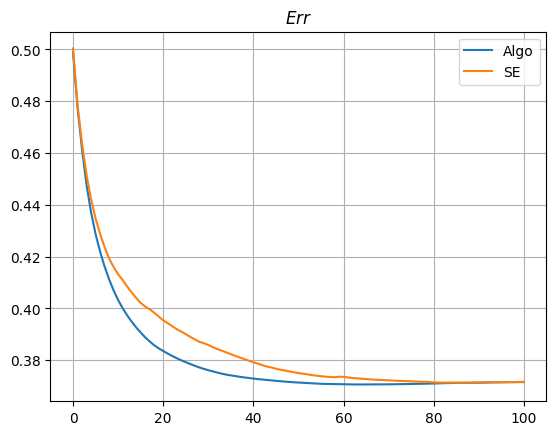

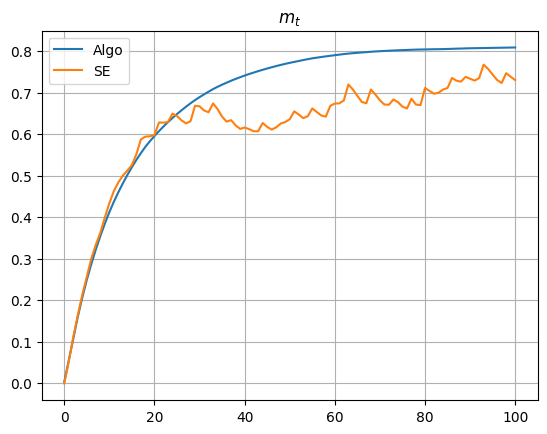

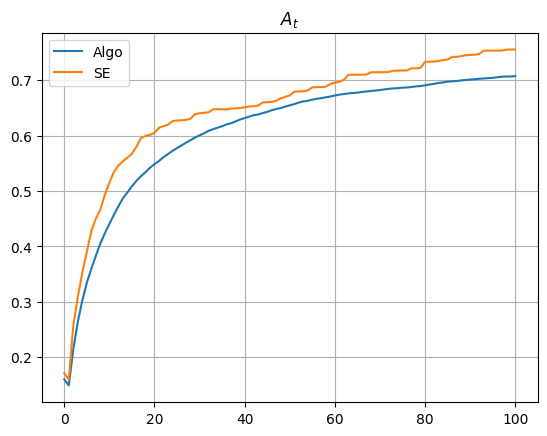

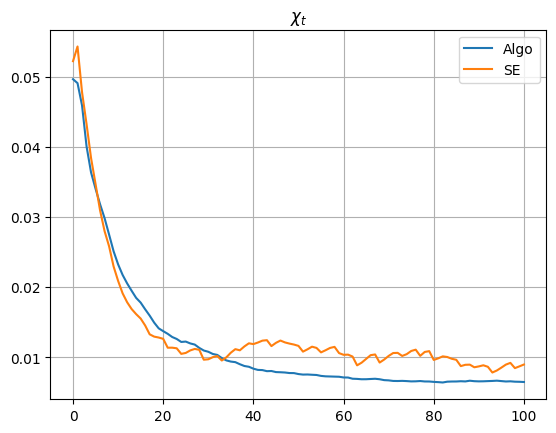

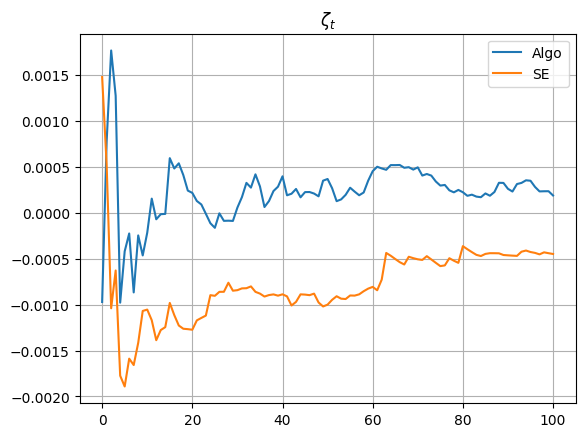

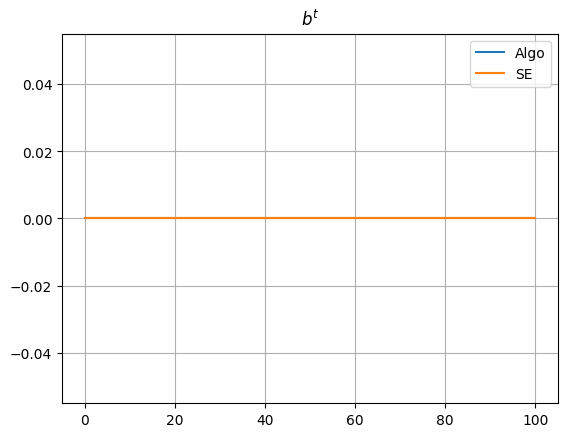

In [49]:
plt.plot(se_callback.history_["population_error"], label="Algo")
plt.plot(torch.tensor(se.error).detach().numpy(), label="SE")
plt.legend()
plt.grid()
plt.title(r"$Err$")
plt.show()

plt.plot(se_callback.history_["weight_signal_alignment"], label="Algo")
plt.plot(torch.tensor(se.weight_signal_alignments).detach().numpy(), label="SE")
plt.legend()
plt.grid()
plt.title(r"$m_t$")
plt.show()

plt.plot(se_callback.history_["unl_usage"], label="Algo")
plt.plot(torch.tensor(se.selection_rate).detach().numpy(), label="SE")
plt.legend()
plt.grid()
plt.title(r"$A_t$")
plt.show()

plt.plot(se_callback.history_['train_label_residual_alignment'], label="Algo")
plt.plot(torch.tensor(se.label_residual_alignments).detach().numpy(), label="SE")
plt.legend()
plt.grid()
plt.title(r"$\chi_t$")
plt.show()

plt.plot(se_callback.history_['train_mean_residual'], label="Algo")
plt.plot(torch.tensor(se.mean_residual).detach().numpy(), label="SE")
plt.legend()
plt.grid()
plt.title(r"$\zeta_t$")
plt.show()

plt.plot(se_callback.history_["bias_term"], label="Algo")
plt.plot(torch.tensor(se.bias).detach().numpy(), label="SE")
plt.legend()
plt.grid()
plt.title(r"$b^t$")
plt.show()

## Autodifferentiation Implementation

The codebase relies on automatic differentiation via PyTorch's torch.autograd engine to compute the memory terms.

At a high level, PyTorch's autograd tracks every tensor with gradient tracking enabled, recursively constructing a Directed Acyclic Graph (DAG) that maps operational dependencies. It then repeatedly applies the chain rule of differentiation, using saved intermediate gradients of elementary functions to compute the final derivatives.

Additionally, the codebase builds upon the torchviz and graphviz libraries to visualize this computational graph. This custom extension enables the annotation of key macroscopic quantities of interest that are otherwise lost when using the standard torchviz visualization functions.


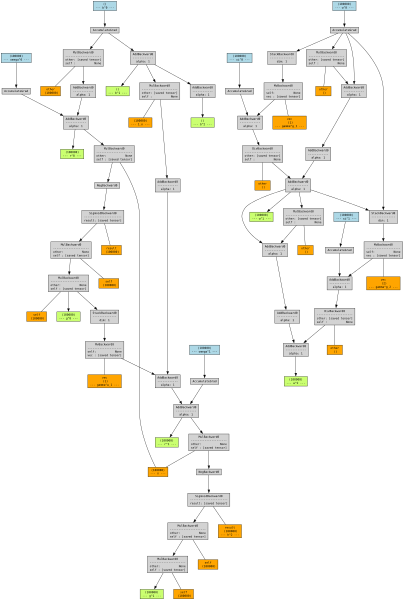

In [32]:
se = MacroscopicStateEvolution(
    data_cfg=se_data_cfg,
    algo_cfg=se_algo_cfg,
    K=K,
    _debug=True
)

se.step(0)
se.step(1)

plot_autograd_dag(
    se=se, 
    t=1, 
    filename="autograd_graph_t1",
    rankdir="TB" 
)